# Import all the packages

In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import matplotlib.dates as mdates
import shap
# import ipywidgets as widgets
import json


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import display, clear_output

# Import & read datafile

In [2]:
#Read datafile 
file_path = "acndata_sessions-caltech.json"

with open(file_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data["_items"])

df.head()
df.columns

Index(['_id', 'clusterID', 'connectionTime', 'disconnectTime',
       'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID',
       'stationID', 'timezone', 'userID', 'userInputs'],
      dtype='object')

In [3]:
df.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
0,5db4e520f9af8b470bd883d5,0039,"Fri, 11 Oct 2019 01:30:56 GMT","Fri, 11 Oct 2019 05:17:48 GMT","Fri, 11 Oct 2019 05:17:43 GMT",13.430,2_39_89_25_2019-10-11 01:30:56.251082,0002,CA-315,2-39-89-25,America/Los_Angeles,000001108,"[{'WhPerMile': 400, 'kWhRequested': 20.0, 'mil..."
1,5db4e520f9af8b470bd883d6,0039,"Fri, 11 Oct 2019 02:50:05 GMT","Fri, 11 Oct 2019 05:39:13 GMT","Fri, 11 Oct 2019 04:55:23 GMT",10.892,2_39_126_20_2019-10-11 02:50:04.891767,0002,CA-310,2-39-126-20,America/Los_Angeles,000001099,"[{'WhPerMile': 400, 'kWhRequested': 24.0, 'mil..."
2,5db4e520f9af8b470bd883d7,0039,"Fri, 11 Oct 2019 03:23:30 GMT","Fri, 11 Oct 2019 04:45:20 GMT","Fri, 11 Oct 2019 04:45:15 GMT",8.612,2_39_139_28_2019-10-11 03:23:30.015263,0002,CA-303,2-39-139-28,America/Los_Angeles,000001263,"[{'WhPerMile': 250, 'kWhRequested': 22.5, 'mil..."
3,5db4e520f9af8b470bd883d8,0039,"Fri, 11 Oct 2019 04:07:17 GMT","Fri, 11 Oct 2019 05:21:38 GMT","Fri, 11 Oct 2019 04:35:54 GMT",1.358,2_39_131_30_2019-10-11 04:07:17.088781,0002,CA-305,2-39-131-30,America/Los_Angeles,000001202,"[{'WhPerMile': 400, 'kWhRequested': 15.2, 'mil..."
4,5db4e520f9af8b470bd883d9,0039,"Fri, 11 Oct 2019 05:07:08 GMT","Fri, 11 Oct 2019 14:50:41 GMT","Fri, 11 Oct 2019 13:26:26 GMT",8.897,2_39_139_28_2019-10-11 05:07:08.410919,0002,CA-303,2-39-139-28,America/Los_Angeles,000001152,"[{'WhPerMile': 300, 'kWhRequested': 6.0, 'mile..."


User inputs are properly displayed instead of the big column it was in the dataset.

Including/excluding rows without "kwh requested" measures:
- by excluding these rows, there will be worse prediction performance.
- however, for predicting the demand kwh requested is needed, so the cases without information about kwh requested are removed from the dataset.


In [4]:
df['userInputs'] = df['userInputs'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else {}
)

user_inputs_df = pd.json_normalize(df['userInputs']).add_prefix('ui_')

df = df.drop(columns=['userInputs']).join(user_inputs_df)


df = df.dropna(subset=['ui_kWhRequested'])

In [5]:
df.columns
df.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,ui_WhPerMile,ui_kWhRequested,ui_milesRequested,ui_minutesAvailable,ui_modifiedAt,ui_paymentRequired,ui_requestedDeparture,ui_userID
0,5db4e520f9af8b470bd883d5,0039,"Fri, 11 Oct 2019 01:30:56 GMT","Fri, 11 Oct 2019 05:17:48 GMT","Fri, 11 Oct 2019 05:17:43 GMT",13.430,2_39_89_25_2019-10-11 01:30:56.251082,0002,CA-315,2-39-89-25,America/Los_Angeles,000001108,400.0,20.0,50.0,239.0,"Fri, 11 Oct 2019 01:31:16 GMT",True,"Fri, 11 Oct 2019 05:29:56 GMT",1108.0
1,5db4e520f9af8b470bd883d6,0039,"Fri, 11 Oct 2019 02:50:05 GMT","Fri, 11 Oct 2019 05:39:13 GMT","Fri, 11 Oct 2019 04:55:23 GMT",10.892,2_39_126_20_2019-10-11 02:50:04.891767,0002,CA-310,2-39-126-20,America/Los_Angeles,000001099,400.0,24.0,60.0,120.0,"Fri, 11 Oct 2019 02:54:16 GMT",True,"Fri, 11 Oct 2019 04:50:05 GMT",1099.0
2,5db4e520f9af8b470bd883d7,0039,"Fri, 11 Oct 2019 03:23:30 GMT","Fri, 11 Oct 2019 04:45:20 GMT","Fri, 11 Oct 2019 04:45:15 GMT",8.612,2_39_139_28_2019-10-11 03:23:30.015263,0002,CA-303,2-39-139-28,America/Los_Angeles,000001263,250.0,22.5,90.0,115.0,"Fri, 11 Oct 2019 03:23:48 GMT",True,"Fri, 11 Oct 2019 05:18:30 GMT",1263.0
3,5db4e520f9af8b470bd883d8,0039,"Fri, 11 Oct 2019 04:07:17 GMT","Fri, 11 Oct 2019 05:21:38 GMT","Fri, 11 Oct 2019 04:35:54 GMT",1.358,2_39_131_30_2019-10-11 04:07:17.088781,0002,CA-305,2-39-131-30,America/Los_Angeles,000001202,400.0,15.2,38.0,173.0,"Fri, 11 Oct 2019 04:07:41 GMT",True,"Fri, 11 Oct 2019 07:00:17 GMT",1202.0
4,5db4e520f9af8b470bd883d9,0039,"Fri, 11 Oct 2019 05:07:08 GMT","Fri, 11 Oct 2019 14:50:41 GMT","Fri, 11 Oct 2019 13:26:26 GMT",8.897,2_39_139_28_2019-10-11 05:07:08.410919,0002,CA-303,2-39-139-28,America/Los_Angeles,000001152,300.0,6.0,20.0,59.0,"Fri, 11 Oct 2019 05:08:20 GMT",True,"Fri, 11 Oct 2019 06:06:08 GMT",1152.0


Rewriting the connection and disconnection time into datetime. 

In [6]:
df['connectionTime'] = pd.to_datetime(df['connectionTime'], errors='coerce', utc=True)
df['disconnectTime'] = pd.to_datetime(df['disconnectTime'], errors='coerce', utc=True)

df['connectionTime'] = df['connectionTime'].dt.tz_convert('America/Los_Angeles')
df['disconnectTime'] = df['disconnectTime'].dt.tz_convert('America/Los_Angeles')

print(df['connectionTime'].dtype)
print(type(df['connectionTime'].iloc[0]))


datetime64[ns, America/Los_Angeles]
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


The code below aggregrates all the kwh requested per hour of the dataset (sum over all cases). The output values correspond to the KWh requested of all charging sessions starting in that specific hour.

In [7]:
df['hour'] = df['connectionTime'].dt.floor('h')

hourly_df = df.groupby('hour')['ui_kWhRequested'].sum().asfreq('h', fill_value=0)
hourly_df = hourly_df.to_frame().rename(columns={'ui_kWhRequested':'kWhRequested'})
hourly_df['hour'] = hourly_df.index

hourly_df.head()

,kWhRequested,hour
hour,,
2019-10-10 18:00:00-07:00,20.0,2019-10-10 18:00:00-07:00
2019-10-10 19:00:00-07:00,24.0,2019-10-10 19:00:00-07:00
2019-10-10 20:00:00-07:00,22.5,2019-10-10 20:00:00-07:00
2019-10-10 21:00:00-07:00,15.2,2019-10-10 21:00:00-07:00
2019-10-10 22:00:00-07:00,6.0,2019-10-10 22:00:00-07:00


The first and last timestep included in the dataset for additional information.

In [8]:
start = df["connectionTime"].min()
end = df["connectionTime"].max()

print(f"Start: {start}")
print(f"End:   {end}")

Start: 2019-10-10 18:30:56-07:00
End:   2021-09-13 18:52:37-07:00


# Data visualisation


Figure below indicates the requested KWh throughout the dataset.

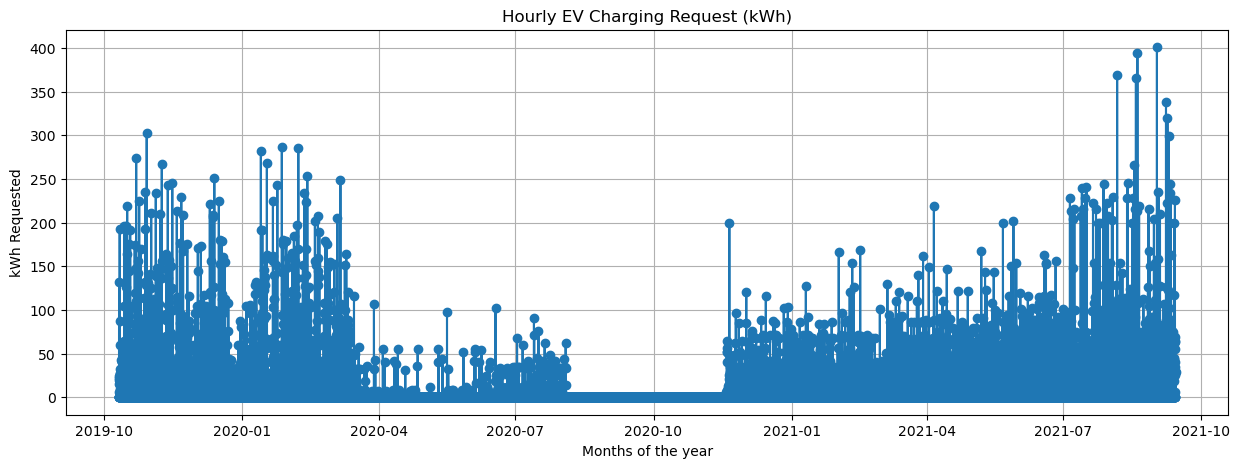

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(hourly_df.index, hourly_df['kWhRequested'], marker='o')
plt.title("Hourly EV Charging Request (kWh)")
plt.xlabel("Months of the year")
plt.ylabel("kWh Requested")
plt.grid(True)
plt.show()


# Feature engineering 

The features hour of day, day of week, month, day of month, time of day, dow_slot are used to predict the model. Additionally, the rolling windows and lags are added. These attributes are chosen in a wide range to enable weekly/daily predictions based on different timeframes. The target variable is the demand, represented by the kWh requested. The kWh requested is used instead of the kWh delivered, because it reflects the true user demand, whereas the delivered energy may be constrained by factors such as limited charging capacity or infrastructure. Therefore, kWh requested provides a more accurate measure of actual demand per time slot.


In [10]:
# Ensure the datetime column exists and is proper type
hourly_df['hour'] = pd.to_datetime(hourly_df['hour'], errors='coerce')

# Extract basic time features
hourly_df['hour_of_day'] = hourly_df['hour'].dt.hour
hourly_df['day_of_week'] = hourly_df['hour'].dt.dayofweek  
hourly_df['month'] = hourly_df['hour'].dt.month
hourly_df['time_of_day'] = hourly_df['hour_of_day'] / 24
hourly_df['dow_slot'] = hourly_df['day_of_week'].astype(str) + "_" + hourly_df['hour_of_day'].astype(str)

In [11]:
hourly_df = hourly_df.rename(columns={'kWhRequested': 'demand'})

# Lag and Rolling features
lags = [1, 2, 3, 6, 12, 24, 48, 168]  # in hours
rolling_windows = {'6h': 6, '12h': 12, '1d': 24, '2d': 48, '1w': 168}


for lag in lags:
    hourly_df[f'demand_lag_{lag}'] = hourly_df['demand'].shift(lag)


for name, window in rolling_windows.items():
    hourly_df[f'demand_roll_mean_{name}'] = hourly_df['demand'].rolling(window).mean().shift(1)
    hourly_df[f'demand_roll_max_{name}'] = hourly_df['demand'].rolling(window).max().shift(1)
    hourly_df[f'demand_roll_min_{name}'] = hourly_df['demand'].rolling(window).min().shift(1)
    hourly_df[f'demand_roll_sum_{name}'] = hourly_df['demand'].rolling(window).sum().shift(1)

# Drop rows with NaNs from lag/rolling
hourly_df = hourly_df.dropna().reset_index(drop=True)

In [12]:
features = [
    'day_of_week', 'month', 'hour_of_day', 'time_of_day', 'dow_slot'
]

for lag in lags:
    features.append(f'demand_lag_{lag}')
for name in rolling_windows.keys():
    features.extend([
        f'demand_roll_mean_{name}',
        f'demand_roll_max_{name}',
        f'demand_roll_min_{name}',
        f'demand_roll_sum_{name}'
    ])

target_col = 'demand'

hourly_df['dow_slot'] = hourly_df['dow_slot'].astype('category')

X = hourly_df[features]
y = hourly_df[target_col]

# Model selection

Splitting test and train data, 80% and 20%, based on time horizon. The 20% test data comes from the final 20% of the dataset. This is to prevent data leakage and model usage of future data to make demand predictions.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

Creating the model with XGBoost regressor. The parameters chosen in this model are based on the hyper parameter tuning (see later part).

In [14]:
# Train XGBoost
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    enable_categorical=True,
    random_state=42
)


model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)  # no negative demand

# Feature importance

Checking the feature importance with SHAP-values to determine which features contribute most to the model predictions.

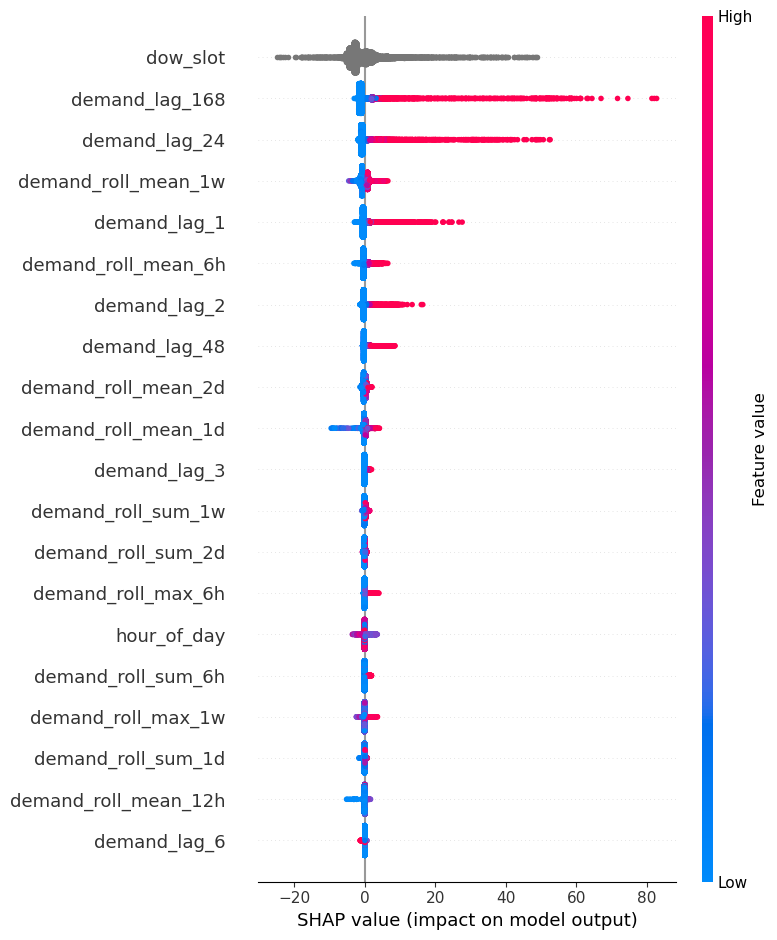

In [15]:
explainer = shap.Explainer(model)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train)

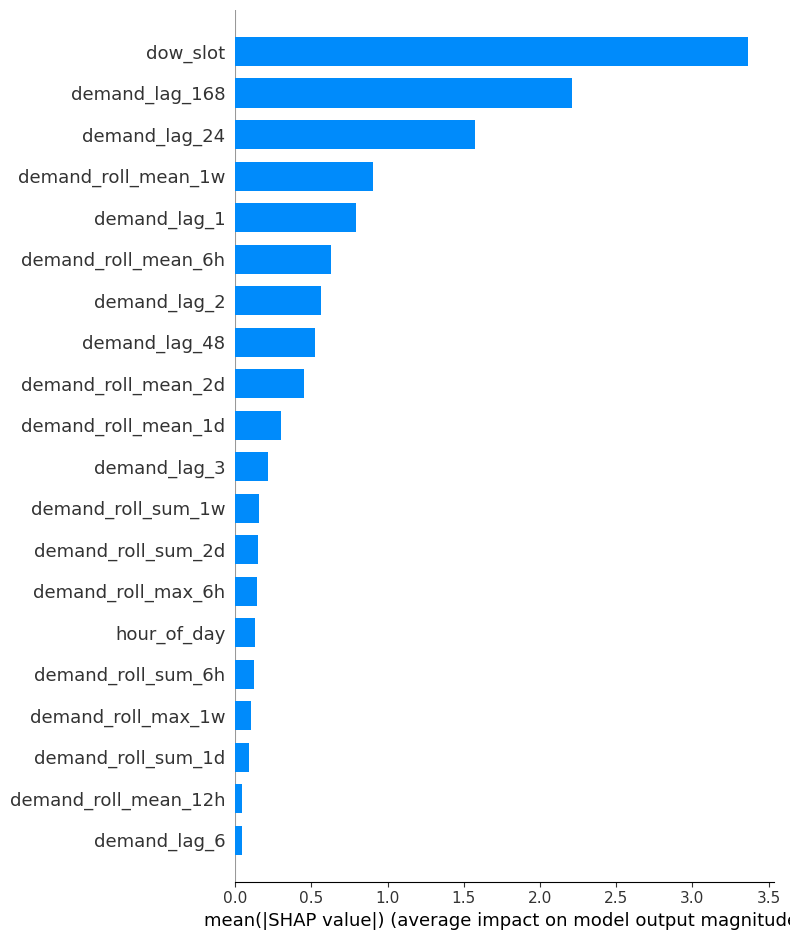

In [16]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

# Hyper parameter tuning

The best combination for the hyperparameters are tested based on a grid search, with the maxdepth, learning rate, n estimators, colsample bytree and objective tested for different "values" as these are the most important hyperparameters to influence the results. The results are shown in a comparison table.

In [17]:
# Hyperparameters tuning by grid search approach
param_grid = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'colsample_bytree': [0.8, 1.0],
    'objective': ["reg:squarederror", "reg:absoluteerror", "reg:pseudohubererror"]
}

#make the grid search
grid_search = GridSearchCV(model, param_grid, cv=3, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

#printing the direct results 
print("Best parameters:", grid_search.best_params_)
print("Best scores:", grid_search.best_score_)

#showing the results in a comparison table
results_df = pd.DataFrame(grid_search.cv_results_)
params_df = results_df['params'].apply(pd.Series)
comparison_table = pd.concat([results_df, params_df], axis=1).drop(columns=['params']).sort_values('mean_test_score', ascending=False)

# Re-train the best model
best_model = grid_search.best_estimator_
model = best_model

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'objective': 'reg:absoluteerror'}
Best scores: -18.15357809483797


In [18]:
# show comparison table 
comparison_table[['learning_rate', 'max_depth', 'n_estimators', 'mean_test_score', 'objective']]

,learning_rate,max_depth,n_estimators,mean_test_score,objective
130,0.05,6,300,-18.153578,reg:absoluteerror
76,0.10,6,300,-18.180877,reg:absoluteerror
133,0.05,6,500,-18.209061,reg:absoluteerror
79,0.10,6,500,-18.286578,reg:absoluteerror
157,0.10,6,300,-18.362170,reg:absoluteerror
...,...,...,...,...,...
92,0.01,4,100,-21.047882,reg:pseudohubererror
82,0.01,3,100,-21.058115,reg:absoluteerror
11,0.01,4,100,-21.091097,reg:pseudohubererror
83,0.01,3,100,-21.148439,reg:pseudohubererror


This result shows absolute error objective performs best, but absolute error does not handle outliers well. With the squarederror objective, it is visible that prediction problems develop when outliers are present (as is shown later in the results). To prevent major predictions issues, the absolute error is excluded from grid search.

In [19]:
# Hyperparameters tuning by grid search approach
param_grid = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'colsample_bytree': [0.8, 1.0],
    'objective': ["reg:squarederror", "reg:pseudohubererror"]
}

#make the grid search
grid_search = GridSearchCV(model, param_grid, cv=3, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

#printing the direct results 
print("Best parameters:", grid_search.best_params_)
print("Best scores:", grid_search.best_score_)

#showing the results in a comparison table
results_df = pd.DataFrame(grid_search.cv_results_)
params_df = results_df['params'].apply(pd.Series)
comparison_table = pd.concat([results_df, params_df], axis=1).drop(columns=['params']).sort_values('mean_test_score', ascending=False)

# Re-train the best model
best_model = grid_search.best_estimator_
model = best_model

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'objective': 'reg:squarederror'}
Best scores: -18.529078067430884


In [20]:
# show comparison table
comparison_table[['learning_rate', 'max_depth', 'n_estimators', 'mean_test_score', 'objective']]

,learning_rate,max_depth,n_estimators,mean_test_score,objective
4,0.01,3,500,-18.529078,reg:squarederror
10,0.01,4,500,-18.549579,reg:squarederror
8,0.01,4,300,-18.651746,reg:squarederror
58,0.01,3,500,-18.744869,reg:squarederror
36,0.10,3,100,-18.768973,reg:squarederror
...,...,...,...,...,...
13,0.01,6,100,-20.989182,reg:pseudohubererror
61,0.01,4,100,-21.047882,reg:pseudohubererror
7,0.01,4,100,-21.091097,reg:pseudohubererror
55,0.01,3,100,-21.148439,reg:pseudohubererror


The results of the "best" model configuration are implemented in the model selection part.

# Model evaluation

The model is evaluated by the RMSE MAE and R2 values, see the project report for more interpretations.

In [21]:
def evaluation(y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return rmse, mae, r2

rmse, mae, r2 = evaluation(y_test, y_pred)

print(f"Test set: RMSE = {rmse:.4f} | MAE = {mae:.4f} | R² = {r2:.4f}")

Test set: RMSE = 35.3954 | MAE = 19.4402 | R² = 0.1427


# Model results

We have made different plots to show the model results:
- heatmap of actual charging demand (overall)
- heatmap of predicted charging demand (overall)
- heatmap of actual charging demand per week
- heatmap of predicted charging demand per week

The results of these plots are interpreted in the report.



## Predicted average charging demand (overall)


In [22]:
test_df = X_test.copy()

test_df['date'] = hourly_df.loc[X_test.index, 'hour']
test_df['actual'] = y_test
test_df['predicted'] = y_pred

test_df['hour'] = test_df['date'].dt.hour
test_df['day_of_week'] = test_df['date'].dt.dayofweek



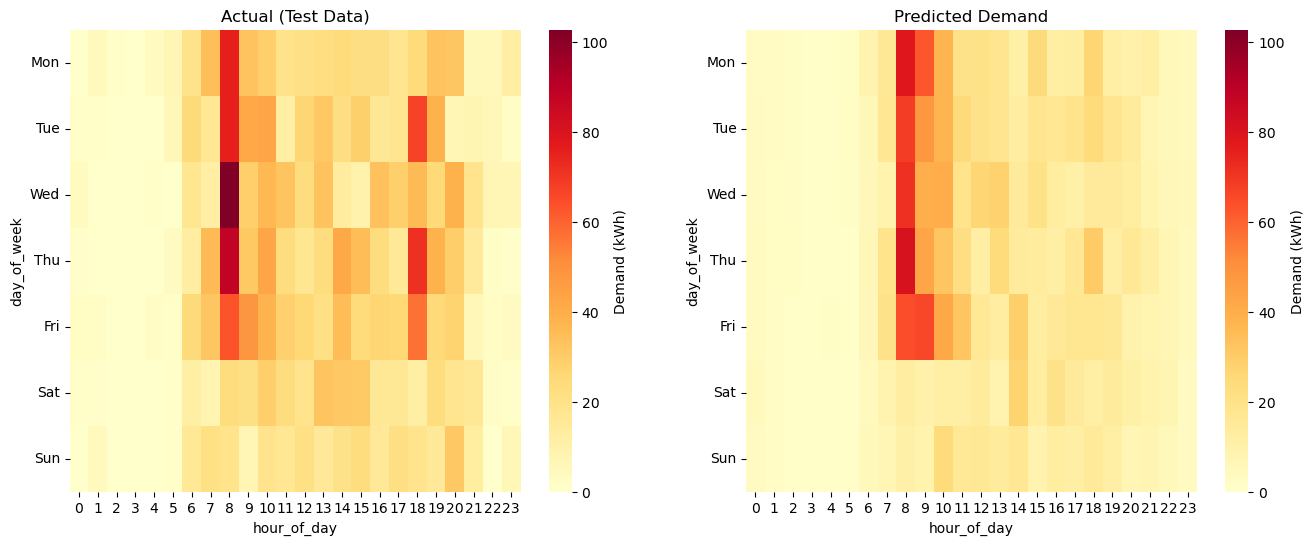

In [23]:
actual_map = test_df.pivot_table(
    index='day_of_week',
    columns='hour_of_day',
    values='actual',
    aggfunc='mean'
)

pred_map = test_df.pivot_table(
    index='day_of_week',
    columns='hour_of_day',
    values='predicted',
    aggfunc='mean'
)

vmin = min(actual_map.min().min(), pred_map.min().min())
vmax = max(actual_map.max().max(), pred_map.max().max())



fig, axes = plt.subplots(1,2, figsize=(16,6))
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]



sns.heatmap(actual_map, cmap="YlOrRd", ax=axes[0], vmin=vmin, vmax=vmax,
            cbar_kws={'label': 'Demand (kWh)'})
axes[0].set_title("Actual (Test Data)")

sns.heatmap(pred_map, cmap="YlOrRd", ax=axes[1], vmin=vmin, vmax=vmax,
            cbar_kws={'label': 'Demand (kWh)'})
axes[1].set_title("Predicted Demand")

axes[0].set_yticklabels(day_labels, rotation=0)
axes[1].set_yticklabels(day_labels, rotation=0)

plt.show()

## Predicted charging demand per week

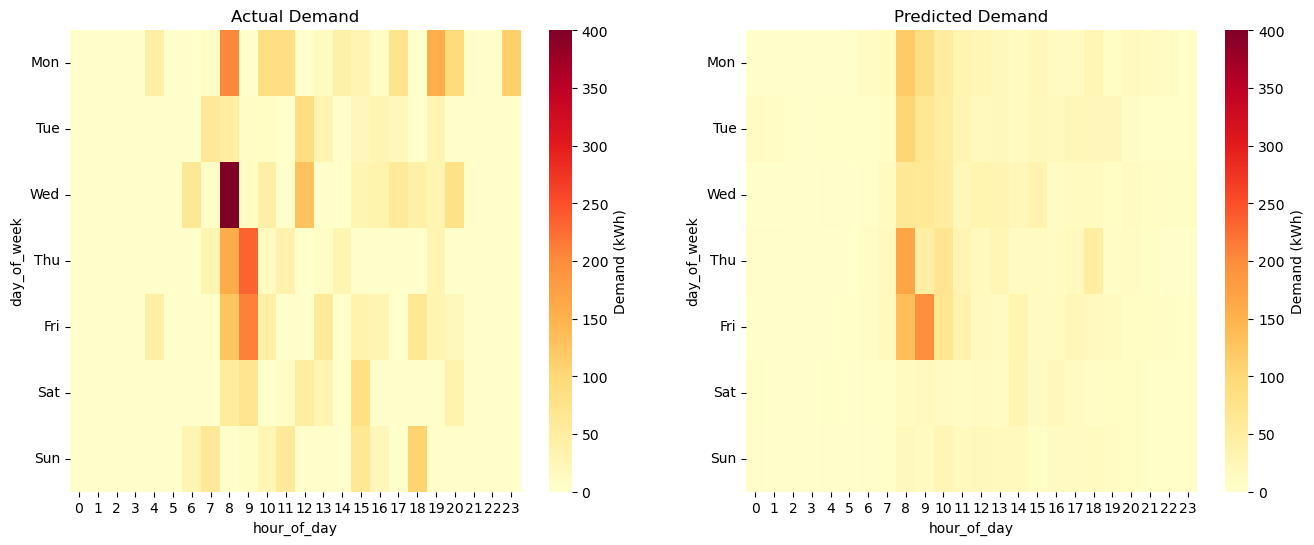

In [24]:
test_df = pd.DataFrame({
    "date": hourly_df.loc[X_test.index, "hour"],
    "actual": y_test,
    "predicted": y_pred
})

test_df["hour_of_day"] = test_df["date"].dt.hour
test_df["day_of_week"] = test_df["date"].dt.dayofweek
test_df["week"] = test_df["date"].dt.isocalendar().week



selected_week = sorted(test_df["week"].unique())[-3]
week_data = test_df[test_df["week"] == selected_week].copy()

actual_map = week_data.pivot_table(
    index="day_of_week",
    columns="hour_of_day",
    values="actual",
    aggfunc="mean"
)

pred_map = week_data.pivot_table(
    index="day_of_week",
    columns="hour_of_day",
    values="predicted",
    aggfunc="mean"
)

vmin = min(actual_map.min().min(), pred_map.min().min())
vmax = max(actual_map.max().max(), pred_map.max().max())


fig, axes = plt.subplots(1,2, figsize=(16,6))
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]



sns.heatmap(actual_map, cmap="YlOrRd", ax=axes[0], vmin=vmin, vmax=vmax,
            cbar_kws={'label': 'Demand (kWh)'})
axes[0].set_title("Actual Demand")

sns.heatmap(pred_map, cmap="YlOrRd", ax=axes[1], vmin=vmin, vmax=vmax,
            cbar_kws={'label': 'Demand (kWh)'})
axes[1].set_title("Predicted Demand")

axes[0].set_yticklabels(day_labels, rotation=0)
axes[1].set_yticklabels(day_labels, rotation=0)

plt.show()


## Rolling Window Backtesting

Evaluating the model using rolling window backtesting to simulate forecasting and preventing data leakage. Using a training window of x days and test window of x days. The metrics are also MAE and RMSE.

#### 1. Fixed window testing -> first 90 days of training then test on rolling 7 days over total set:

In [25]:
train_window_days = 30
train_window = train_window_days*24  # 90 days of training (in hours)
test_window_days = 7
test_window = test_window_days*24  # 14 days of testing (in hours)

daily_results = []

# Rolling backtest: 
for start in range(0, len(hourly_df) - train_window - test_window, 24):
    
    # Split train and test
    train = hourly_df.iloc[0:train_window] # Static training window
    test = hourly_df.iloc[start+train_window:start+train_window+test_window]
    
    X_train = train[features]
    y_train = train[target_col]
    X_test = test[features]
    y_test = test[target_col]
    
    # Model setup same as for the XGBoost demand regression above
    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=1.0,
        objective="reg:squarederror",
        enable_categorical=True,
        random_state=42
    )

    # Fit the model on selected training window
    model.fit(X_train, y_train)
    
    # Predict & Evaluate with constraint on non-negative preds
    preds = model.predict(X_test)
    preds = np.clip(preds, 0, None)
    
    # Compute mae,rmse per day
    for day in range(test_window_days):
        start_idx = day*24
        end_idx = (day+1)*24
        
        y_true_day = y_test.iloc[start_idx:end_idx]
        y_pred_day = preds[start_idx:end_idx]
        
        mae = mean_absolute_error(y_true_day, y_pred_day)
        rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
        
        daily_results.append({
            "train_start": train["hour"].iloc[0],
            "train_end": train["hour"].iloc[-1],
            "window_start": test["hour"].iloc[0],
            "window_end": test["hour"].iloc[-1],
            "horizon_day": day+1,
            "MAE": mae,
            "RMSE": rmse
        })

# Aggregate daily metrics
daily_df = pd.DataFrame(daily_results)
summary_by_day = daily_df.groupby("horizon_day")[["MAE", "RMSE"]].mean().reset_index()

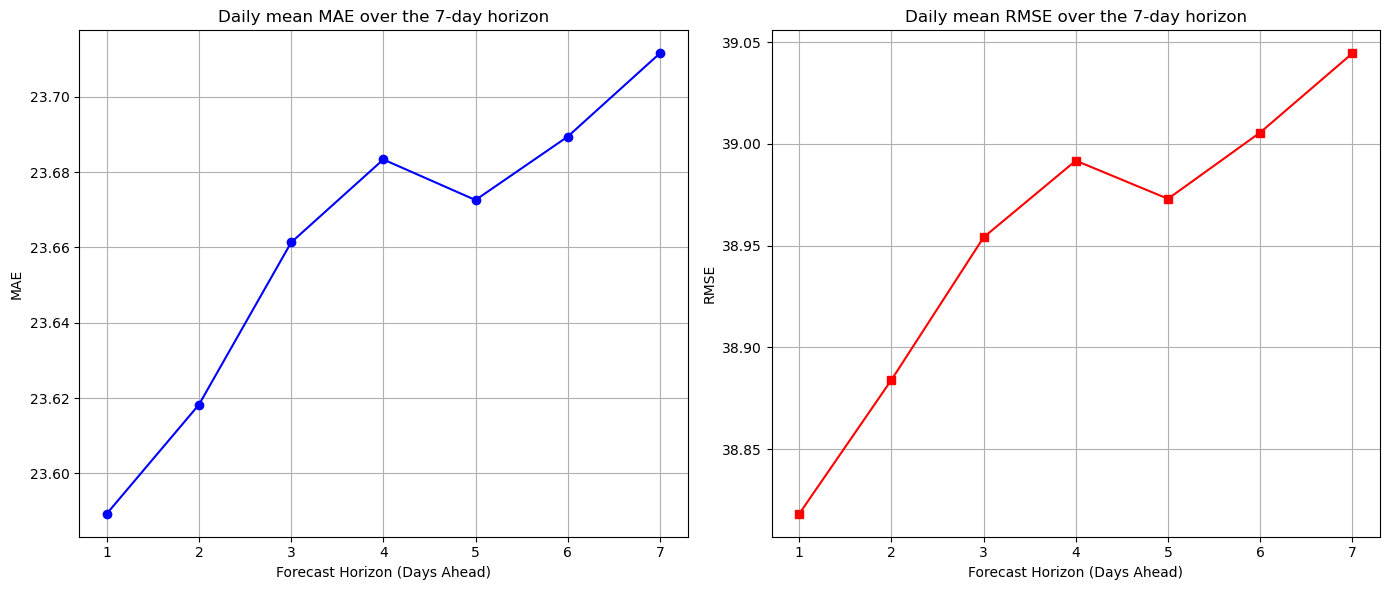

In [26]:
# Plotting results of MAE, RMSE using summary_by_day df over the 14-day horizon
fig, axes = plt.subplots(ncols=2, figsize=(14,6))

axes[0].plot(summary_by_day['horizon_day'], summary_by_day['MAE'], marker='o', color='blue')
axes[0].set_xlabel('Forecast Horizon (Days Ahead)')
axes[0].set_ylabel('MAE')
axes[0].set_title('Daily mean MAE over the 7-day horizon')
axes[0].set_xticks(np.arange(1, 8, 1))
axes[0].grid(True)

axes[1].plot(summary_by_day['horizon_day'], summary_by_day['RMSE'], marker='s', color='red')
axes[1].set_xlabel('Forecast Horizon (Days Ahead)')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Daily mean RMSE over the 7-day horizon')
axes[1].set_xticks(np.arange(1, 8, 1))
axes[1].grid(True)

plt.tight_layout()
plt.show()

The analysis shows that both MAE and RMSE increase as the forecast horizon extends from 1 to 7 days. This is expected because uncertainty naturally grows the further we predict into the future.

#### 2. Rolling window of 90 days to predict the next 7 days

In [27]:
train_window_days = 30
train_window = train_window_days * 24
test_window_days = 7
test_window = test_window_days * 24

daily_results = []

# Rolling backtest with rolling training window (retraining every day)
for start in range(0, len(hourly_df) - train_window - test_window, 24):
    
    # Define rolling training and test windows
    train = hourly_df.iloc[start:start+train_window] # Rolling from start
    test = hourly_df.iloc[start+train_window:start+train_window+test_window]
    
    X_train = train[features]
    y_train = train[target_col]
    X_test = test[features]
    y_test = test[target_col]

    # Model training as before
    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=1.0,
        objective="reg:squarederror",
        enable_categorical=True,
        random_state=42
    )
    
    # Fit the model on selected training window
    model.fit(X_train, y_train)
    
    # Predict the model & evaluate with constraint on non-negative preds
    preds = model.predict(X_test)
    preds = np.clip(preds, 0, None)
    
    # Compute mae,rmse per day
    for day in range(test_window_days):
        start_idx = day * 24
        end_idx = (day + 1) * 24
        
        y_true_day = y_test.iloc[start_idx:end_idx]
        y_pred_day = preds[start_idx:end_idx]
        
        mae = mean_absolute_error(y_true_day, y_pred_day)
        rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
        
        daily_results.append({
            "train_start": train["hour"].iloc[0],
            "train_end": train["hour"].iloc[-1],
            "window_start": test["hour"].iloc[0],
            "window_end": test["hour"].iloc[-1],
            "horizon_day": day + 1,
            "MAE": mae,
            "RMSE": rmse
        })


# Aggregate metrics across all rolling windows per horizon day
daily_df_rolling = pd.DataFrame(daily_results)
summary_by_day_rolling = daily_df_rolling.groupby("horizon_day")[["MAE", "RMSE"]].mean().reset_index()

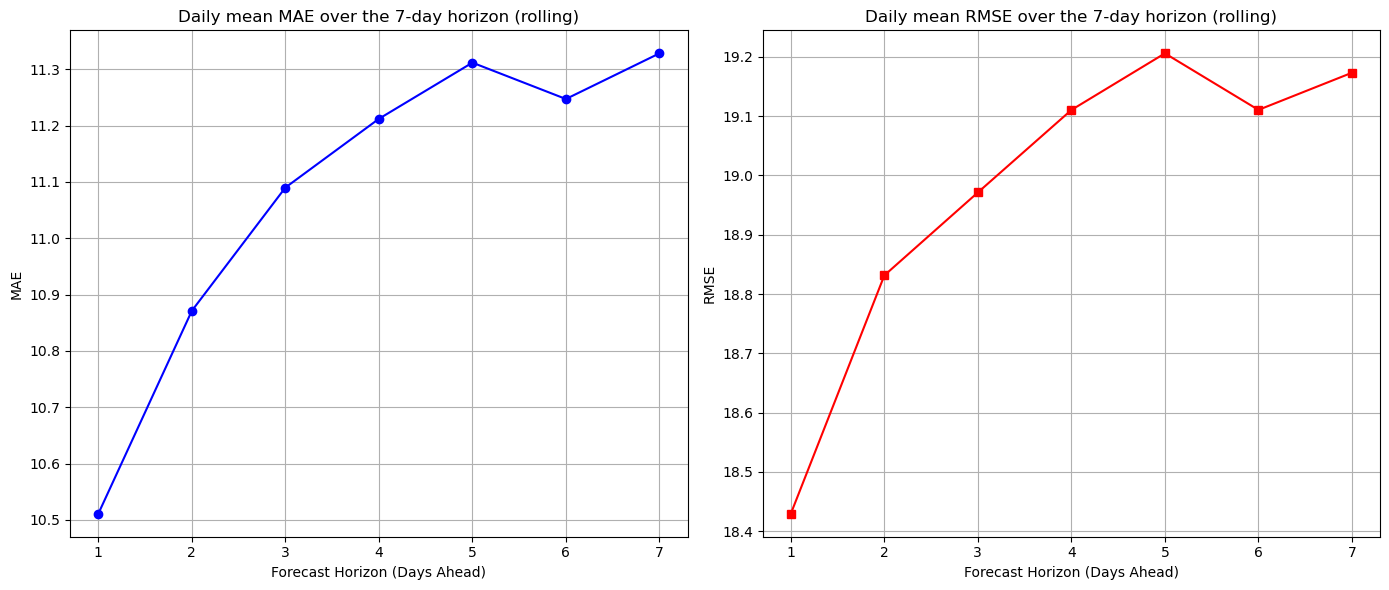

In [28]:
fig, axes = plt.subplots(ncols=2, figsize=(14,6))

axes[0].plot(summary_by_day_rolling['horizon_day'], summary_by_day_rolling['MAE'], marker='o', color='blue')
axes[0].set_xlabel('Forecast Horizon (Days Ahead)')
axes[0].set_ylabel('MAE')
axes[0].set_title('Daily mean MAE over the 7-day horizon (rolling)')
axes[0].set_xticks(np.arange(1, 8, 1))
axes[0].grid(True)

axes[1].plot(summary_by_day_rolling['horizon_day'], summary_by_day_rolling['RMSE'], marker='s', color='red')
axes[1].set_xlabel('Forecast Horizon (Days Ahead)')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Daily mean RMSE over the 7-day horizon (rolling)')
axes[1].set_xticks(np.arange(1, 8, 1))
axes[1].grid(True)

plt.tight_layout()
plt.show()

The analysis shows that both MAE and RMSE increase as the forecast horizon extends from 1 to 7 days. This is expected because uncertainty naturally grows the further we predict into the future

#### 3. Comparison static vs rolling training window

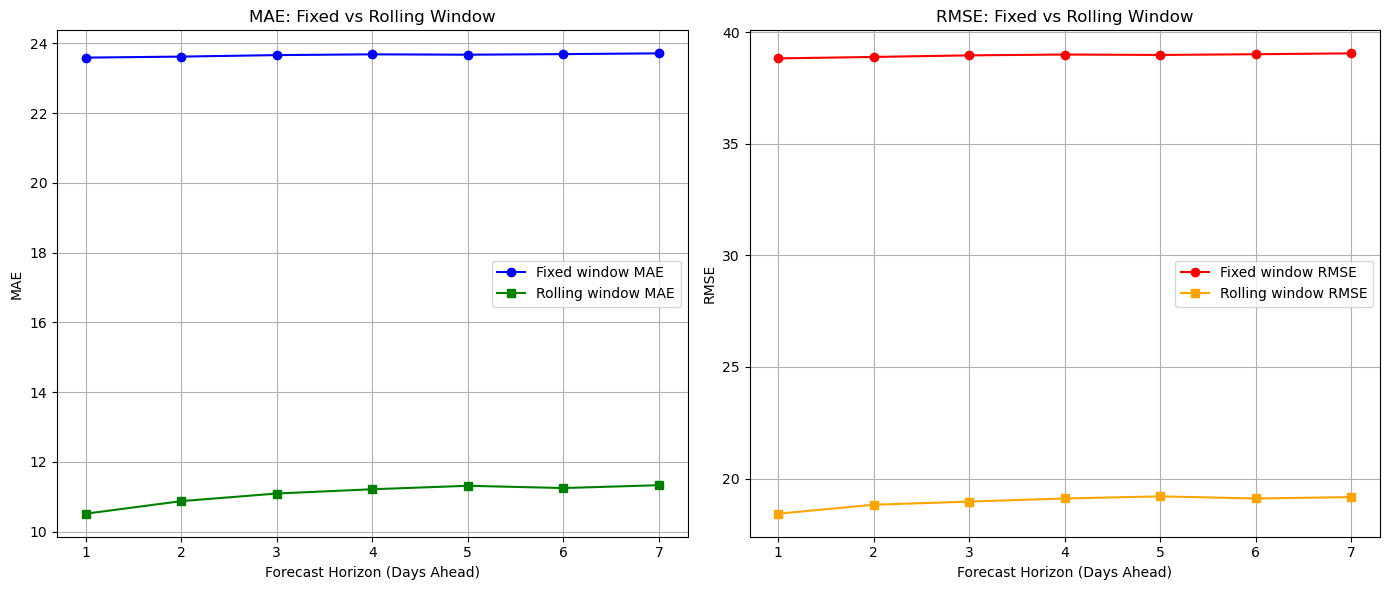

In [29]:
fig, axes = plt.subplots(ncols=2, figsize=(14,6))

# MAE subplot
axes[0].plot(summary_by_day['horizon_day'], summary_by_day['MAE'], marker='o', color='blue', label='Fixed window MAE')
axes[0].plot(summary_by_day_rolling['horizon_day'], summary_by_day_rolling['MAE'], marker='s', color='green', label='Rolling window MAE')
axes[0].set_xlabel('Forecast Horizon (Days Ahead)')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE: Fixed vs Rolling Window')
axes[0].set_xticks(np.arange(1, 8, 1))
axes[0].grid(True)
axes[0].legend()

# RMSE subplot
axes[1].plot(summary_by_day['horizon_day'], summary_by_day['RMSE'], marker='o', color='red', label='Fixed window RMSE')
axes[1].plot(summary_by_day_rolling['horizon_day'], summary_by_day_rolling['RMSE'], marker='s', color='orange', label='Rolling window RMSE')
axes[1].set_xlabel('Forecast Horizon (Days Ahead)')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE: Fixed vs Rolling Window')
axes[1].set_xticks(np.arange(1, 8, 1))
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

Rolling training window errors produce smaller results than static training window errors as the model adapts to the newer datapoints, resulting in less overfitting thus error.